In [34]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
hdf5_file = "/home/zakarianarjis/Downloads/particles_3d_mf.hdf5"
with h5py.File(hdf5_file, 'r') as f:
    img = f["data"][20]
# Normalize the image to [0, 1] range
img = (img - np.min(img)) / (np.max(img) - np.min(img))
# Display the image

In [6]:
img.shape

(201, 16, 16)

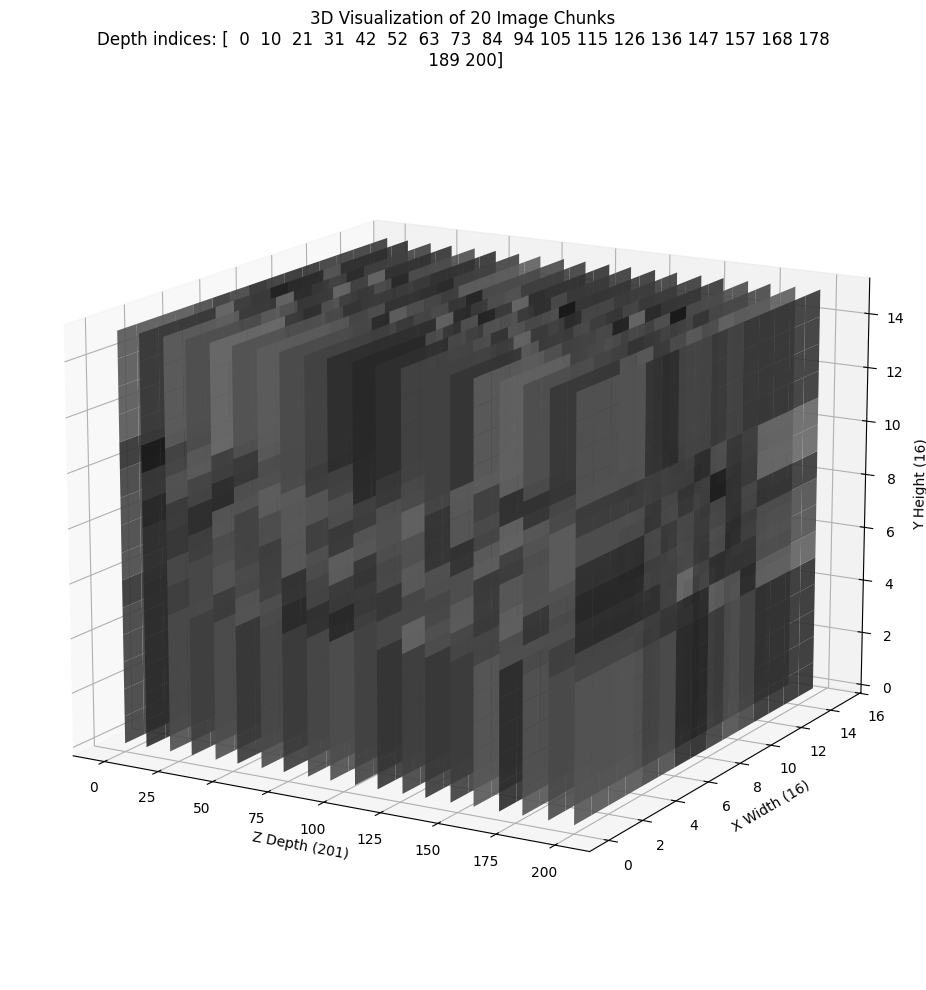

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_chunks(img, num_chunks=6):
    """
    Plot evenly spaced chunks from a 3D image as grayscale slices in 3D space.
    
    Args:
        img: numpy array of shape (201, 16, 16)
        num_chunks: number of chunks to plot (default: 6)
    
    Returns:
        chunk_indices: array of depth indices that were plotted
    """
    depth, height, width = img.shape
    
    # Calculate evenly spaced indices for chunks
    chunk_indices = np.linspace(0, depth - 1, num_chunks, dtype=int)
    
    # Create 3D plot
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create coordinate grids for plotting
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)
    
    # Plot each chunk
    for i, z_idx in enumerate(chunk_indices):
        # Get the 16x16 slice at depth z_idx
        slice_2d = img[z_idx, :, :]
        
        # Create X coordinate plane for this slice (horizontal progression)
        Z_plane = np.full_like(Y, z_idx, dtype=float)
        
        # Plot the surface rotated to be horizontal with grayscale colormap
        surf = ax.plot_surface(Z_plane, X, Y, facecolors=plt.cm.gray(slice_2d/slice_2d.max()), 
                              alpha=0.9, linewidth=0, antialiased=True)
    
    # Set labels and title
    ax.set_xlabel('Z Depth (201)')
    ax.set_ylabel('X Width (16)')
    ax.set_zlabel('Y Height (16)')
    ax.set_title(f'3D Visualization of {num_chunks} Image Chunks\nDepth indices: {chunk_indices}')
    
    # Set the viewing angle for better horizontal visualization
    ax.view_init(elev=15, azim=-60)
    
    # Adjust layout
    plt.tight_layout()
    #Save the figure
    plt.savefig("3d_chunks_plot.png")
    # Show the plot 
    plt.show()


plot_3d_chunks(img, num_chunks=20)

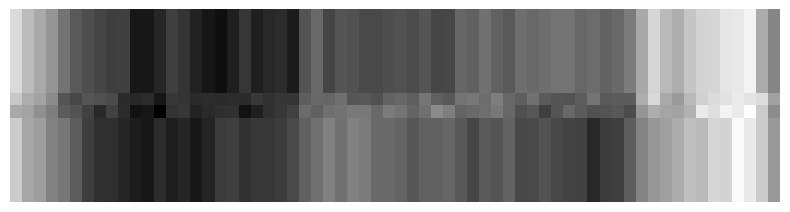

In [51]:
hdf5_file = "/home/zakarianarjis/Downloads/brightfield_particles.hdf5"
with h5py.File(hdf5_file, 'r') as f:
    img = f["data"][20]
# Normalize the image to [0, 1] range
img = (img - np.min(img)) / (np.max(img) - np.min(img
))
# Resize the image by sampling
import torch
from torchvision import transforms
resize_transform = transforms.Resize((16, 64))
img = resize_transform(torch.tensor(img).unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0).numpy()


# Display the image
fig, ax = plt.subplots(figsize=(8, 8),dpi=100)
ax.axis('off')
ax.imshow(img, cmap='gray')
plt.tight_layout()
plt.savefig("2d_particle.png")
plt.show()

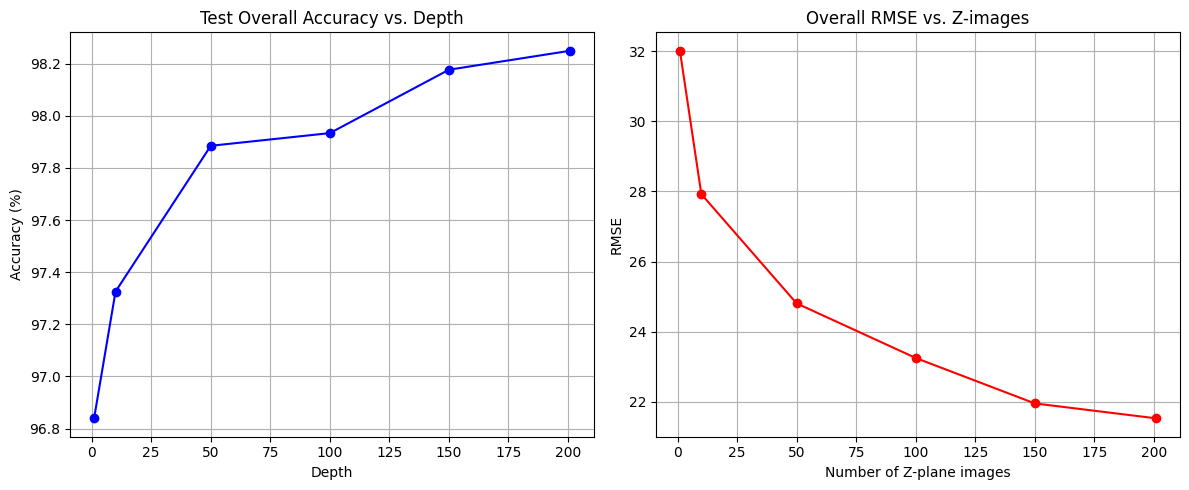

In [ ]:
zxy_results_paths ={
    "201": "/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zxy_2025-07-10_17-11-10",
    "1":"/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zxy_2025-07-22_14-20-51",
    "10":"/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zxy_2025-07-22_13-05-45",
    "50":"/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zxy_2025-07-22_13-47-19",
    "100":"/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zxy_2025-07-22_13-54-05",
    "150":"/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zxy_2025-07-22_14-02-46"
}
import os
import json
import matplotlib.pyplot as plt

def plot_depth_vs_metrics(results_paths):
    depths = []
    test_accuracies = []
    overall_rmses = []

    for depth_str, dir_path in results_paths.items():
        depth = int(depth_str)
        json_files = [f for f in os.listdir(dir_path) if f.endswith(".json")]
        if not json_files:
            print(f"No JSON file found in {dir_path}")
            continue

        json_path = os.path.join(dir_path, json_files[0])
        with open(json_path, "r") as f:
            results = json.load(f)

        try:
            accuracy = results["test_metrics"]["test_overall_metrics"]["overall_accuracy_percentage"]
            rmse = results["test_metrics"]["test_overall_metrics"]["overall_rmse"]
        except KeyError as e:
            print(f"Missing key in {json_path}: {e}")
            continue

        depths.append(depth)
        test_accuracies.append(accuracy)
        overall_rmses.append(rmse)

    # Sort by depth for proper plotting
    sorted_data = sorted(zip(depths, test_accuracies, overall_rmses))
    sorted_depths, sorted_accuracies, sorted_rmses = zip(*sorted_data)

    # Plotting
    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(sorted_depths, sorted_accuracies, marker='o', color='blue')
    plt.title("Test Overall Accuracy vs. Depth")
    plt.xlabel("Number of Z-plane images")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)

    # RMSE plot
    plt.subplot(1, 2, 2)
    plt.plot(sorted_depths, sorted_rmses, marker='o', color='red')
    plt.title("Overall RMSE vs. Z-images")
    plt.xlabel("Number of Z-plane images")
    plt.ylabel("RMSE")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("depth_vs_metrics.png")
    plt.show()

plot_depth_vs_metrics(zxy_results_paths)